**Milestone-02: Temporal Trend Analysis**
**Visualizing U.S. Disaster Declarations**

Objective

This milestone focuses on analyzing how disaster declarations change over time. The analysis includes:

1. Yearly temporal trends

2. Comparison of disaster types across years

3. Monthly seasonality patterns

4. Interpretation of long-term changes

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\tanus\Desktop\Tanu\US Disaster Visualization\data\disasters.csv")

# Display first 5 rows
print(df.head())

  Declaration Number Declaration Type Declaration Date State County  \
0               DR-1         Disaster       05/02/1953    GA    NaN   
1               DR-2         Disaster       05/15/1953    TX    NaN   
2               DR-3         Disaster       05/29/1953    LA    NaN   
3               DR-4         Disaster       06/02/1953    MI    NaN   
4               DR-5         Disaster       06/06/1953    MT    NaN   

  Disaster Type              Disaster Title  Start Date    End Date  \
0       Tornado                     Tornado  05/02/1953  05/02/1953   
1       Tornado  Tornado and Heavy Rainfall  05/15/1953  05/15/1953   
2         Flood                       Flood  05/29/1953  05/29/1953   
3       Tornado                     Tornado  06/02/1953  06/02/1953   
4         Flood                      Floods  06/06/1953  06/06/1953   

   Close Date Individual Assistance Program Individuals & Households Program  \
0  06/01/1954                           Yes                       

**Step 1: Time Data Validation**
Before conducting temporal analysis, it is necessary to validate the date column. Incorrect or missing date values can distort trend analysis and lead to misleading conclusions.

After converting the "Declaration Date" column to datetime format, year and month features were extracted for aggregation purposes. No critical missing date values were found, ensuring the dataset is suitable for time-based analysis.

In [ ]:
############################################ STEP-1 ####################################

# Check current dtype 
print(df['Declaration Date'].dtype)
# Converting into datetime format
df['Declaration Date'] = pd.to_datetime(df['Declaration Date'], errors='coerce')
print(df['Declaration Date'].dtype)

# Count missing dates
missing_dates = df['Declaration Date'].isna().sum()
print("Missing/Invalid dates:", missing_dates)

# Checking Logical Date Range
print("Earliest date:", df['Declaration Date'].min())
print("Latest date:", df['Declaration Date'].max())

# Checking year month distribution
df['year'] = df['Declaration Date'].dt.year
df['month'] = df['Declaration Date'].dt.month

print(df['year'].value_counts().sort_index().head())
print(df['month'].value_counts().sort_index())

object
datetime64[ns]
Missing/Invalid dates: 0
Earliest date: 1953-05-02 00:00:00
Latest date: 2017-02-14 00:00:00
year
1953    13
1954    17
1955    18
1956    16
1957    16
Name: count, dtype: int64
month
1     4630
2     3526
3     4633
4     3636
5     4231
6     4041
7     3883
8     3602
9     8281
10    2673
11    1341
12    1708
Name: count, dtype: int64


**Step 2: Yearly Trend Analysis**
This section evaluates how the total number of disaster declarations varies across years.

**Interpretation**
1. The graph shows the total number of disaster declarations per year.
2. There is a noticeable upward trend, particularly after the 1970s and more prominently after the 1990s.
3. Sudden spikes in certain years may correspond to major natural events or policy-related changes in disaster reporting.

Overall, the data indicates a long-term increase in disaster declarations.

year
1953    13
1954    17
1955    18
1956    16
1957    16
dtype: int64


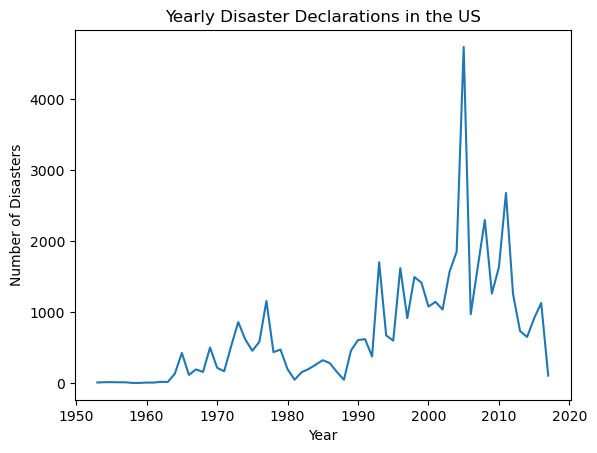

In [7]:
################################################## STEP-2 ######################################

# Year Extracting
df['year'] = df['Declaration Date'].dt.year

# Group data by year
yearly_counts = df.groupby('year').size()
print(yearly_counts.head())

# Line chart
plt.figure()
plt.plot(yearly_counts.index, yearly_counts.values)

plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.title("Yearly Disaster Declarations in the US")
plt.show()

**Step 3: Smoothed Trend Analysis**
To better understand long-term patterns, a 5-year moving average is applied to smooth short-term fluctuations in yearly disaster counts.

**Interpretation: Incident Type Trends Over Time**
1.	The analysis shows that Severe Storms and Floods are the most frequent disaster types across the years.
2.	The trend shows that Severe Storms have the fastest growth over time. From the late 1990s onward, the number of severe storm declarations increases significantly compared to other disaster types.
3.	Most disaster types do not show a strong declining trend. However:

Some categories such as Drought or Landslides appear less frequently and remain relatively stable over time.

Certain incident types may show temporary declines in specific years, but they do not demonstrate a consistent long-term decrease.

Disaster Type  Chemical  Dam/Levee Break  Drought  Earthquake  Fire  Flood  \
year                                                                         
1953                  0                0        0           0     1      5   
1954                  0                0        0           1     0      7   
1955                  0                0        0           0     0      8   
1956                  0                0        0           0     1      7   
1957                  0                0        0           0     0     10   

Disaster Type  Human Cause  Hurricane  Ice  Mud/Landslide  Other  Snow  Storm  \
year                                                                            
1953                     0          0    0              0      1     0      0   
1954                     0          7    0              0      1     0      0   
1955                     0          7    0              0      1     0      0   
1956                     0          2    0      

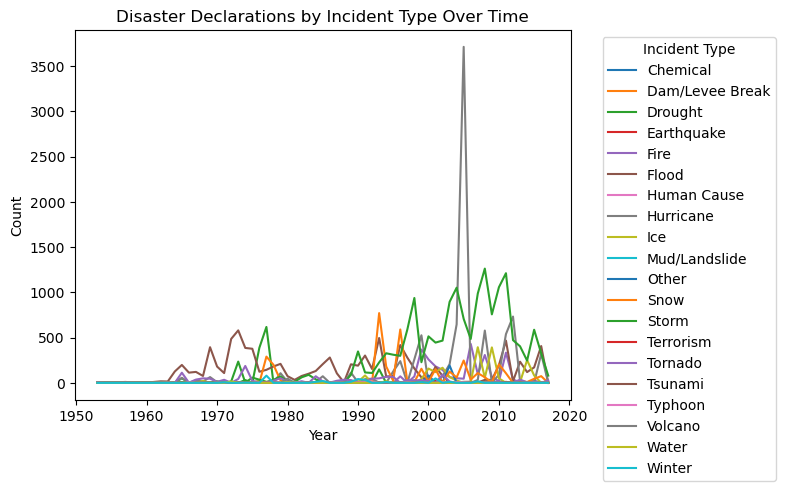

In [8]:
################################################## STEP-3 ################################################

# Group by year + incident type and count
incident_trends = df.groupby(['year', 'Disaster Type']).size()

# Converting into table format
incident_trends = incident_trends.unstack(fill_value=0)
print(incident_trends.head())

# Multi-line chart
plt.figure()

for incident in incident_trends.columns:
    plt.plot(incident_trends.index, incident_trends[incident], label=incident)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Disaster Declarations by Incident Type Over Time")
plt.legend(title="Incident Type", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()


**Step 4: Incident Type Trends Over Time**
This section compares the top five most frequent disaster types across years to understand which categories dominate and how they evolve over time.

**Interpretation: Seasonality Analysis**
1. The analysis shows that late summer and early fall months (typically August, September, and October) have the highest number of disaster declarations.
Justification:

    * Severe storms occur frequently due to thunderstorms, tornadoes, and heavy rainfall.

    * Flooding is a common consequence of storms and hurricanes.

    * These events affect multiple states and therefore generate more disaster declarations.
2. Yes, the data indicates a seasonal pattern in disaster occurrences.Disaster declarations tend to increase during mid-to-late year months and decrease during winter months, suggesting that disasters are influenced by seasonal weather patterns.
Possible Reasons:

    * Increased frequency of extreme weather events

    * Improved disaster reporting systems

    * Greater federal disaster assistance coverage
3. Yes, a recurring annual pattern can be observed:

Lower disaster counts in early months (January–March)
Gradual increase during spring and early summer
Peak activity in late summer and early fall
Decline toward the end of the year

month
1     4630
2     3526
3     4633
4     3636
5     4231
6     4041
7     3883
8     3602
9     8281
10    2673
11    1341
12    1708
dtype: int64


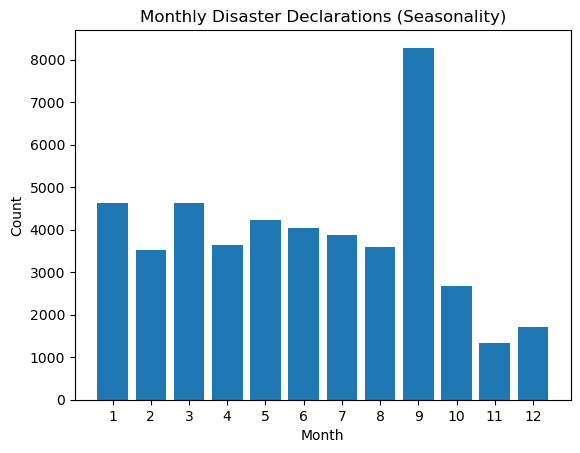

In [9]:
################################################ STEP-4 ####################################################################

# Extract month
df['month'] = df['Declaration Date'].dt.month

# Group by month and count
monthly_counts = df.groupby('month').size().sort_index()
print(monthly_counts)

# Bar chart
plt.figure()
plt.bar(monthly_counts.index, monthly_counts.values)

plt.xlabel("Month")
plt.ylabel("Count")
plt.title("Monthly Disaster Declarations (Seasonality)")
plt.xticks(range(1, 13))

plt.show()

**Step 5: Seasonality Analysis (Monthly Trends)**
This section examines whether disaster declarations follow seasonal patterns by analyzing their distribution across months.

**Interpretation**
This confirms that the increase observed in the yearly trend is not caused only by occasional spikes but reflects a consistent long-term growth in disaster events or declarations.

In [10]:
######################################## STEP-5 ##################################################################

# Yearly disaster counts
yearly_counts = df.groupby('year').size()

# 3-year moving average
rolling_3 = yearly_counts.rolling(window=3).mean()

# 5-year moving average
rolling_5 = yearly_counts.rolling(window=5).mean()

# Year-over-Year % Change of growth rate
growth_rate = yearly_counts.pct_change() * 100
print(growth_rate.head())

# Identify Top 5 peak years
top_years = yearly_counts.sort_values(ascending=False).head(5)
print("Top 5 Peak Disaster Years:", top_years)

year
1953          NaN
1954    30.769231
1955     5.882353
1956   -11.111111
1957     0.000000
dtype: float64
Top 5 Peak Disaster Years: year
2005    4736
2011    2680
2008    2300
2004    1853
1993    1705
dtype: int64
